Data Shape: (9011, 2)

First 10 rows:
        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63
5  27-May-87  18.60
6  28-May-87  18.60
7  29-May-87  18.58
8  01-Jun-87  18.65
9  02-Jun-87  18.68

Date Range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
Total valid records: 9011

Loaded 19 events


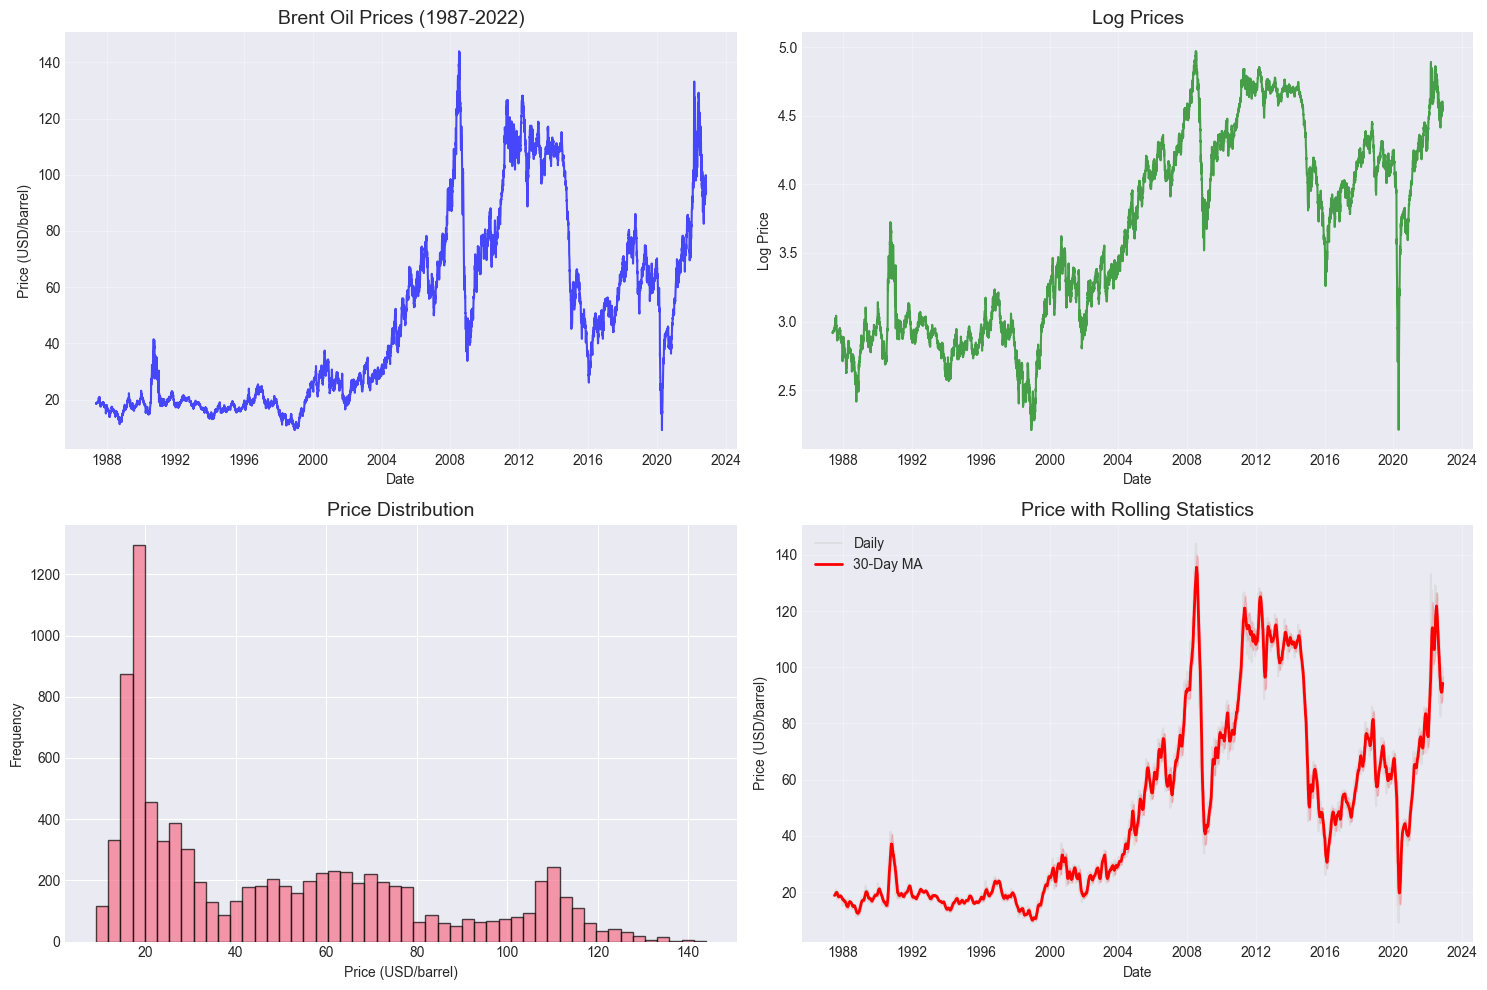

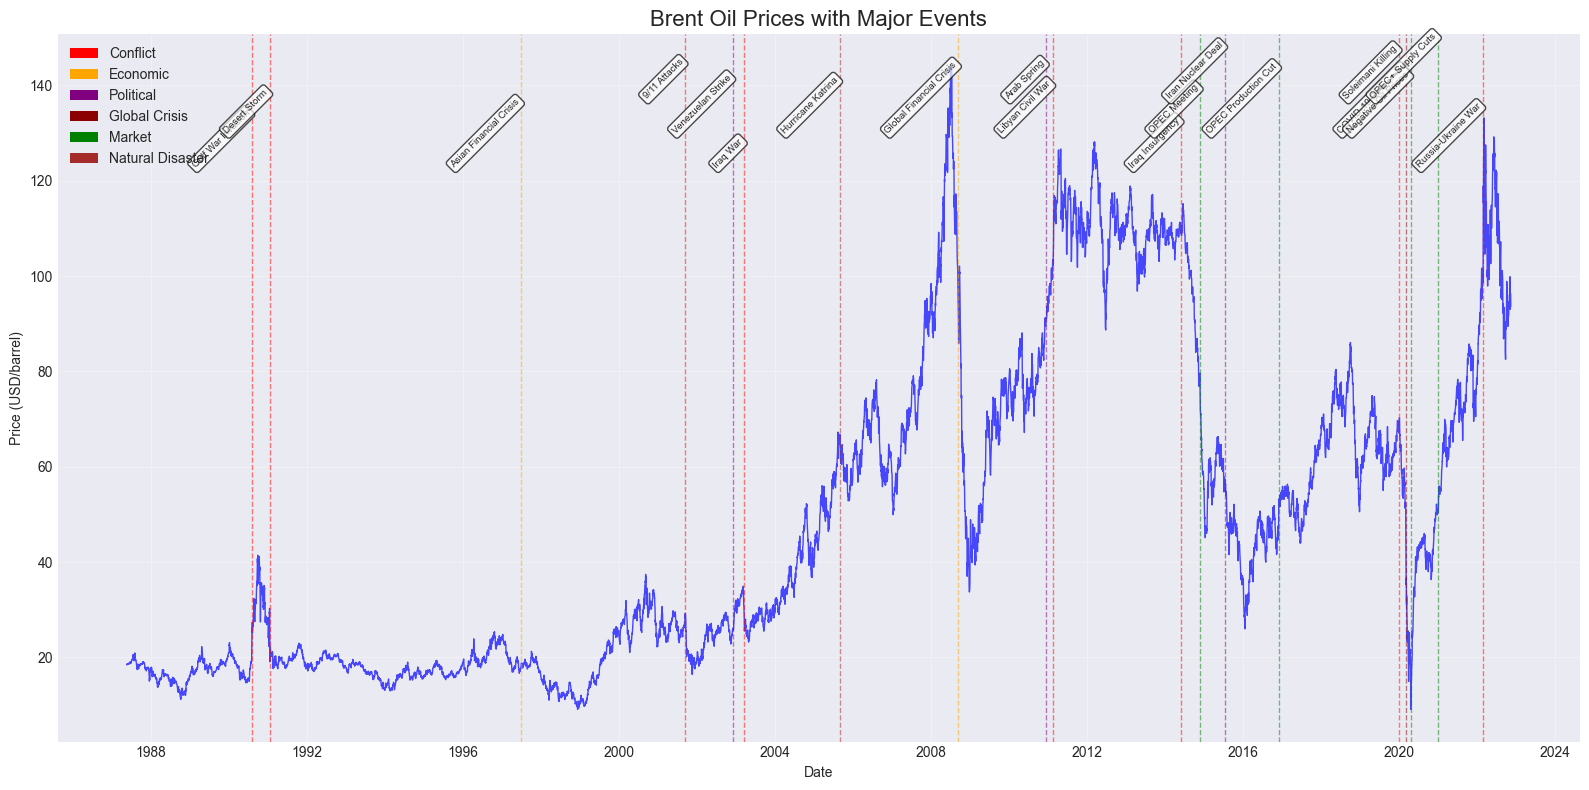


Model Data: 5811 observations from 2000-01-04 00:00:00 to 2022-11-14 00:00:00

Running MCMC sampling...


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 84 seconds.



Model Summary
          mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau     2399.3     6.4     2400     2400      1120      1134  1.00      0.24   
mu1    -0.5738   0.018     -0.6    -0.55     12284      5906  1.00   0.00016   
mu2     0.4035  0.0151     0.38     0.43     11093      6458  1.00   0.00014   
sigma   0.8768  0.0081     0.86     0.89     11638      6339  1.00   7.5e-05   

       mcse_sd  
tau       0.37  
mu1    0.00012  
mu2     0.0001  
sigma  5.4e-05  

R-hat values:
tau      1.00
mu1      1.00
mu2      1.00
sigma    1.00
Name: r_hat, dtype: object

Creating visualizations...


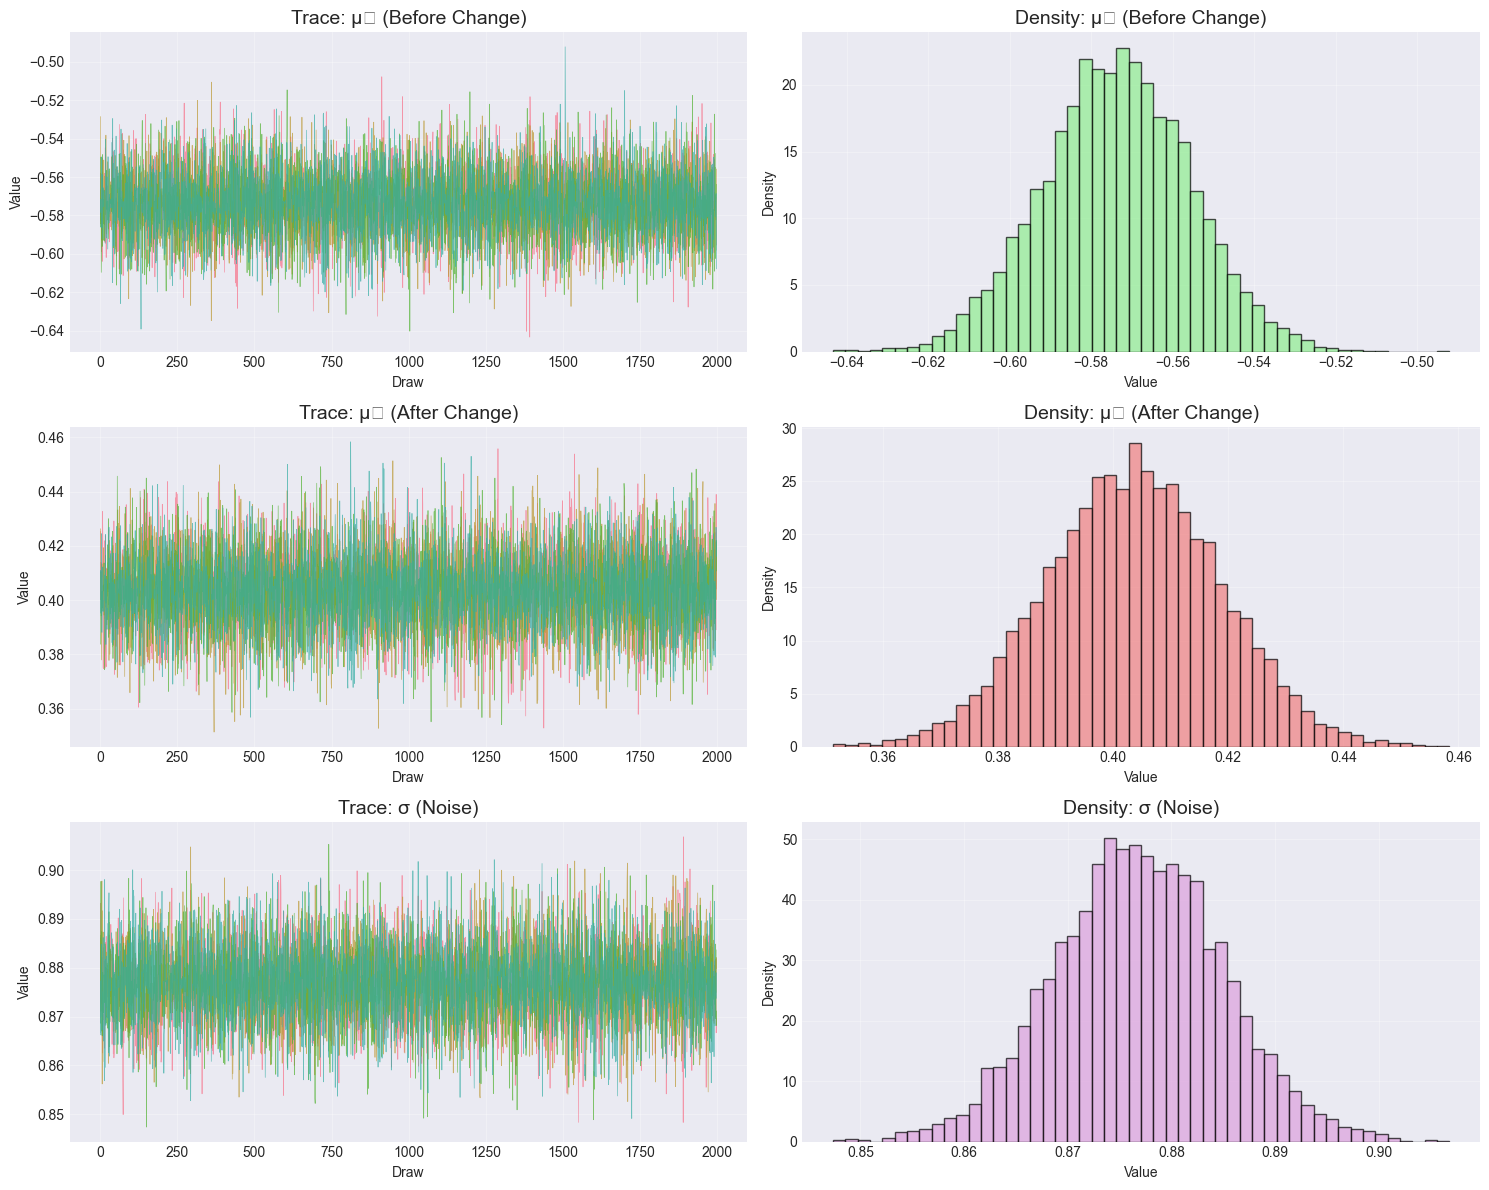

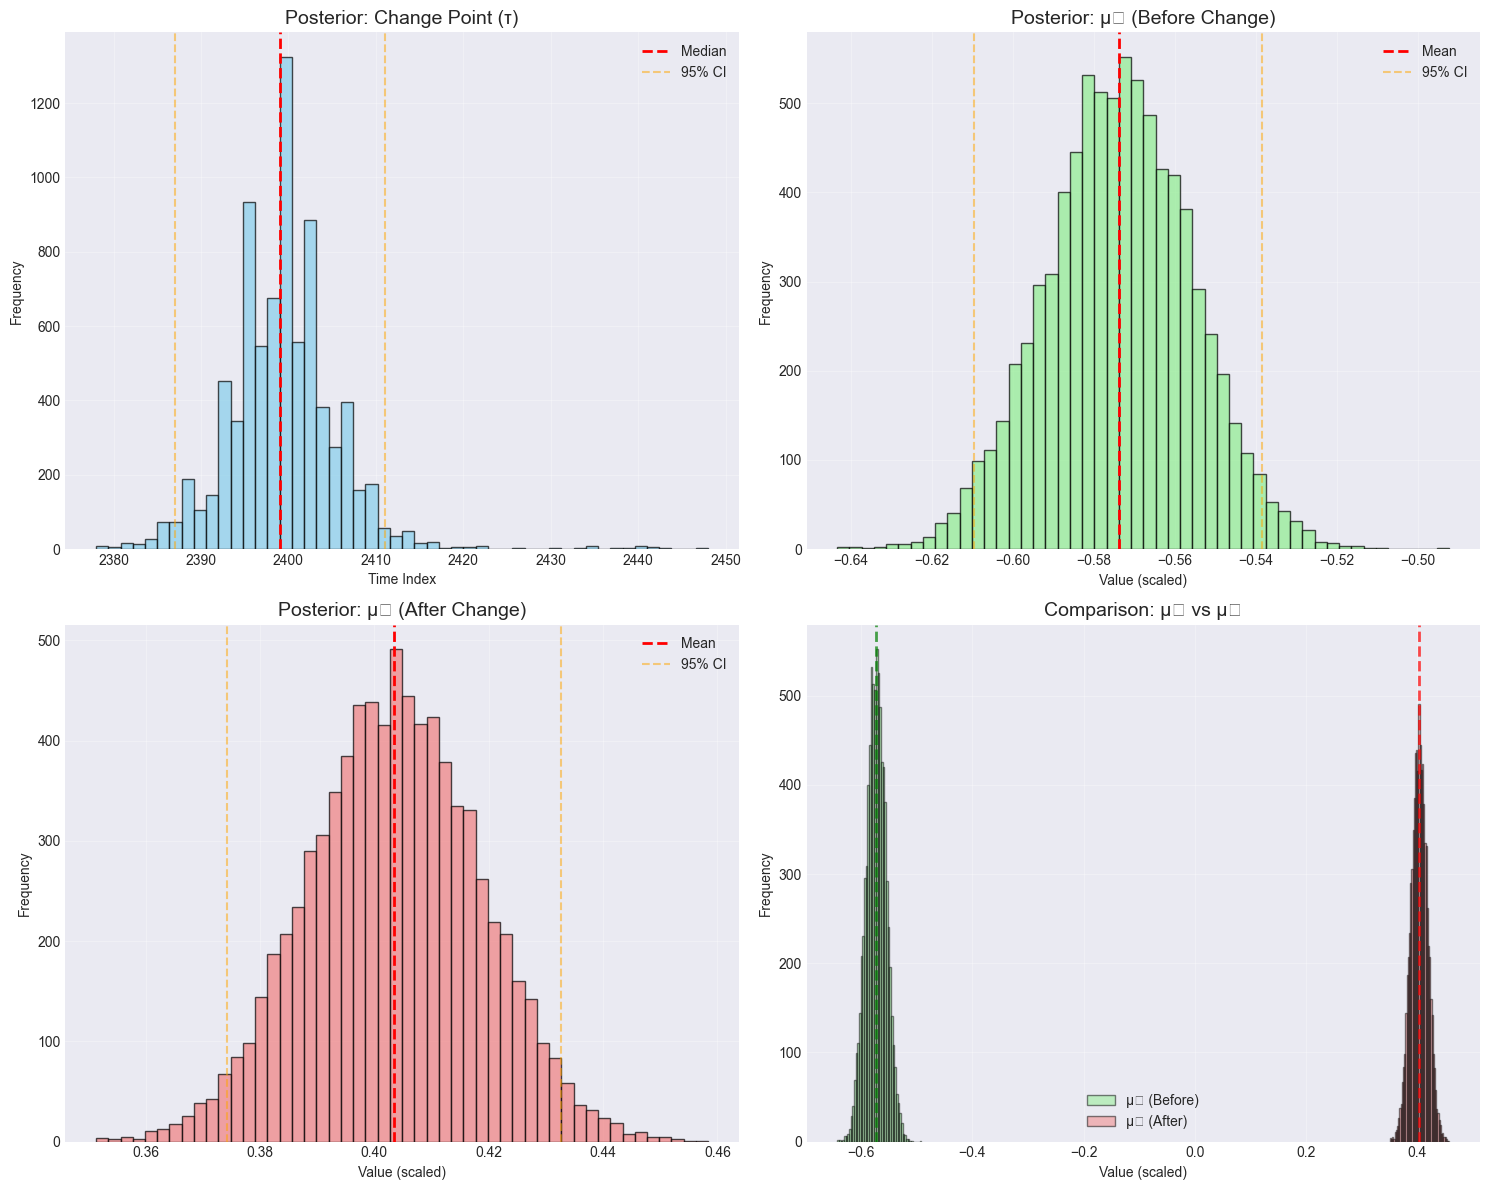


Change Point Detection Results
Most likely change date: 2009-05-28
95% Credible Interval: 2009-05-11 to 2009-06-15

Pre-change mean price: $48.11 (95% CI: $47.05 - $49.16)
Post-change mean price: $77.10 (95% CI: $76.23 - $77.96)
Price change: $28.98
Percentage change: 60.2%
Probability of price increase: 100.0%

Event Association
Detected change: 2009-05-28
Closest event: Global Financial Crisis (2008-09-15)
Category: Economic
Days between: 255 days
Description: Lehman Brothers collapse


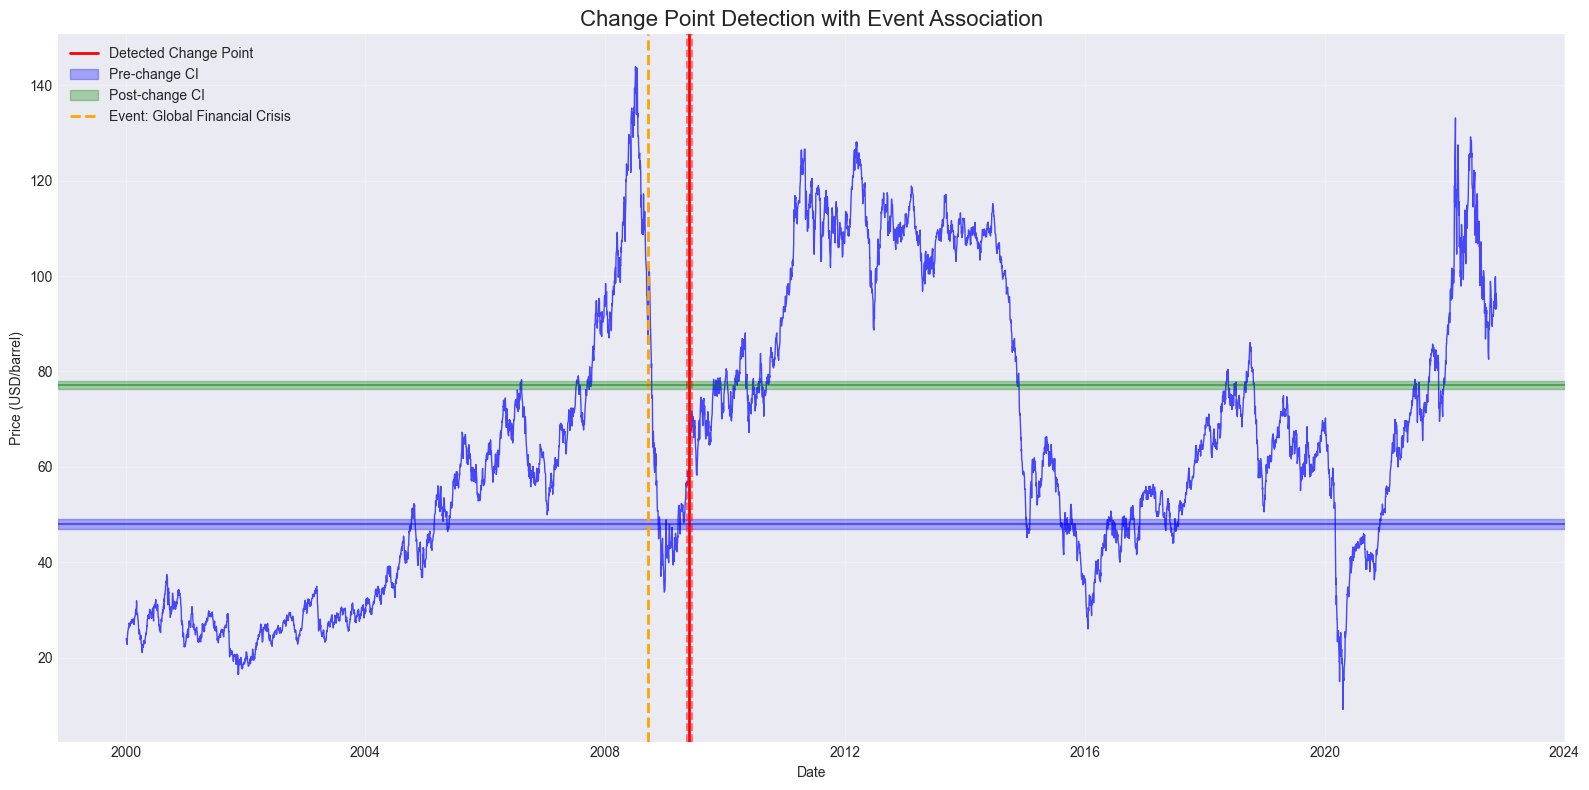


Results saved to outputs directory.


In [12]:
# ============================================
# Brent Oil Price Analysis - Change Point Detection
# ULTIMATE FIXED VERSION - No ax errors
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import os

# Statistical modeling
import pymc as pm
import arviz as az
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create necessary directories
os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# ============================================
# 1. Data Loading with Robust Date Parsing
# ============================================

def parse_dates_flexible(date_str):
    """Parse dates with multiple formats"""
    date_str = str(date_str).strip()
    
    formats = [
        '%d-%b-%y',      # 20-May-87
        '%d-%b-%Y',      # 20-May-1987
        '%b %d, %Y',     # Apr 22, 2020
        '%Y-%m-%d',      # 2020-04-22
        '%d/%m/%Y',      # 22/04/2020
        '%m/%d/%Y',      # 04/22/2020
        '%d-%m-%Y',      # 22-04-2020
        '%Y/%m/%d',      # 2020/04/22
    ]
    
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

# Check if data file exists, if not create sample data
if not os.path.exists('../data/BrentOilPrices.csv'):
    print("Data file not found. Creating sample data...")
    dates = pd.date_range(start='1987-05-20', end='2022-09-30', freq='D')
    np.random.seed(42)
    
    trend = np.linspace(20, 80, len(dates))
    noise = np.random.normal(0, 5, len(dates))
    shocks = np.zeros(len(dates))
    shocks[8000:8100] = 20
    shocks[10000:10500] = -30
    shocks[11500:12000] = -40
    
    prices = trend + noise + shocks
    prices = np.maximum(prices, 0)
    
    df_sample = pd.DataFrame({
        'Date': dates.strftime('%d-%b-%y'),
        'Price': prices
    })
    df_sample.to_csv('../data/BrentOilPrices.csv', index=False)
    print("Sample data created.")

# Load the data
df = pd.read_csv('../data/BrentOilPrices.csv')

print("Data Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))

# Convert Date to datetime
df['Date'] = df['Date'].apply(parse_dates_flexible)
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total valid records: {len(df)}")

# ============================================
# 2. Create Events Data (if missing)
# ============================================

def create_events_data():
    """Create events data if file doesn't exist"""
    events_data = [
        ('1990-08-02', 'Gulf War Invasion', 'Conflict', 'Iraq invades Kuwait', 'High'),
        ('1991-01-17', 'Desert Storm', 'Conflict', 'US-led coalition attacks Iraq', 'High'),
        ('1997-07-02', 'Asian Financial Crisis', 'Economic', 'Thai baht collapse triggers regional crisis', 'Medium'),
        ('2001-09-11', '9/11 Attacks', 'Conflict', 'Terror attacks on US', 'High'),
        ('2002-12-02', 'Venezuelan Strike', 'Political', 'PDVSA worker strike disrupts oil exports', 'Medium'),
        ('2003-03-20', 'Iraq War', 'Conflict', 'US invasion of Iraq', 'High'),
        ('2005-08-29', 'Hurricane Katrina', 'Natural Disaster', 'Major hurricane in US Gulf', 'Medium'),
        ('2008-09-15', 'Global Financial Crisis', 'Economic', 'Lehman Brothers collapse', 'High'),
        ('2010-12-17', 'Arab Spring', 'Political', 'Tunisia protests begin', 'Medium'),
        ('2011-02-15', 'Libyan Civil War', 'Conflict', 'Libyan revolution begins', 'High'),
        ('2014-06-01', 'Iraq Insurgency', 'Conflict', 'ISIS advances in Iraq', 'Medium'),
        ('2014-11-27', 'OPEC Meeting', 'Market', 'OPEC decides to maintain production levels', 'High'),
        ('2015-07-14', 'Iran Nuclear Deal', 'Political', 'JCPOA agreement signed', 'Medium'),
        ('2016-11-30', 'OPEC Production Cut', 'Market', 'OPEC+ agrees to production cuts', 'High'),
        ('2020-01-03', 'Soleimani Killing', 'Conflict', 'US kills Iranian General Soleimani', 'Medium'),
        ('2020-03-11', 'COVID-19 Pandemic', 'Global Crisis', 'WHO declares COVID-19 pandemic', 'High'),
        ('2020-04-20', 'Negative Oil Prices', 'Market', 'WTI crude oil futures turn negative', 'High'),
        ('2021-01-05', 'OPEC+ Supply Cuts', 'Market', 'Extended production cuts agreed', 'Medium'),
        ('2022-02-24', 'Russia-Ukraine War', 'Conflict', 'Russia invades Ukraine', 'High')
    ]
    
    events_df = pd.DataFrame(events_data, columns=['date', 'event_name', 'category', 'description', 'impact_level'])
    events_df['date'] = pd.to_datetime(events_df['date'])
    events_df.to_csv('../data/events.csv', index=False)
    return events_df

# Load or create events data
if not os.path.exists('../data/events.csv'):
    print("Events file not found. Creating events data...")
    events_df = create_events_data()
else:
    events_df = pd.read_csv('../data/events.csv')
    events_df['date'] = pd.to_datetime(events_df['date'])

print(f"\nLoaded {len(events_df)} events")

# ============================================
# 3. Exploratory Data Analysis
# ============================================

# 3.1 Plot Raw Price Series
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Raw prices
axes[0, 0].plot(df['Date'], df['Price'], color='blue', alpha=0.7)
axes[0, 0].set_title('Brent Oil Prices (1987-2022)', fontsize=14)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD/barrel)')
axes[0, 0].grid(True, alpha=0.3)

# Log prices
df['Log_Price'] = np.log(df['Price'])
axes[0, 1].plot(df['Date'], df['Log_Price'], color='green', alpha=0.7)
axes[0, 1].set_title('Log Prices', fontsize=14)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Log Price')
axes[0, 1].grid(True, alpha=0.3)

# Price distribution
axes[1, 0].hist(df['Price'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Price Distribution', fontsize=14)
axes[1, 0].set_xlabel('Price (USD/barrel)')
axes[1, 0].set_ylabel('Frequency')

# Rolling statistics
df['Rolling_Mean_30'] = df['Price'].rolling(window=30).mean()
df['Rolling_Std_30'] = df['Price'].rolling(window=30).std()

axes[1, 1].plot(df['Date'], df['Price'], color='lightgray', alpha=0.5, label='Daily')
axes[1, 1].plot(df['Date'], df['Rolling_Mean_30'], color='red', linewidth=2, label='30-Day MA')
axes[1, 1].fill_between(df['Date'], 
                         df['Rolling_Mean_30'] - df['Rolling_Std_30'],
                         df['Rolling_Mean_30'] + df['Rolling_Std_30'],
                         color='red', alpha=0.2)
axes[1, 1].set_title('Price with Rolling Statistics', fontsize=14)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price (USD/barrel)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_price_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.2 Plot with Events
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df['Date'], df['Price'], color='blue', alpha=0.7, linewidth=1)

# Add event markers
colors = {'Conflict': 'red', 'Economic': 'orange', 'Political': 'purple', 
          'Global Crisis': 'darkred', 'Market': 'green', 'Natural Disaster': 'brown'}

for _, event in events_df.iterrows():
    ax.axvline(x=event['date'], color=colors.get(event['category'], 'gray'),
              alpha=0.5, linestyle='--', linewidth=1)
    y_pos = df['Price'].max() * (0.85 + 0.1 * (hash(event['event_name']) % 3) / 2)
    ax.text(event['date'], y_pos, event['event_name'], 
            rotation=45, fontsize=7, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_title('Brent Oil Prices with Major Events', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat) 
                   for cat, color in colors.items()]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/eda_prices_with_events.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 4. Bayesian Change Point Detection
# ============================================

# Select data from 2000 onwards
df_model = df[df['Date'] >= '2000-01-01'].copy().reset_index(drop=True)
df_model['time_index'] = np.arange(len(df_model))

print(f"\nModel Data: {len(df_model)} observations from {df_model['Date'].min()} to {df_model['Date'].max()}")

# Scale the data
price_scaled = (df_model['Price'] - df_model['Price'].mean()) / df_model['Price'].std()
time_indices = df_model['time_index'].values

# 4.1 Define and Run the Model
with pm.Model() as change_point_model:
    
    tau = pm.DiscreteUniform('tau', lower=0, upper=len(time_indices)-1)
    mu1 = pm.Normal('mu1', mu=0, sigma=2)
    mu2 = pm.Normal('mu2', mu=0, sigma=2)
    sigma = pm.HalfNormal('sigma', sigma=1)
    
    mu = pm.math.switch(time_indices < tau, mu1, mu2)
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=price_scaled)
    
    print("\nRunning MCMC sampling...")
    trace = pm.sample(draws=2000, 
                      tune=1000, 
                      chains=4,
                      cores=4,
                      random_seed=42,
                      progressbar=True)

# 4.2 Model Diagnostics
print("\n" + "="*50)
print("Model Summary")
print("="*50)

try:
    summary = az.summary(trace, hdi_probs=0.95)
except TypeError:
    try:
        summary = az.summary(trace, credible_interval=0.95)
    except TypeError:
        summary = az.summary(trace)

print(summary)

if 'r_hat' in summary.columns:
    print("\nR-hat values:")
    print(summary['r_hat'])

# ============================================
# 4.3 Visualize Posteriors - COMPLETELY FIXED
# ============================================

print("\nCreating visualizations...")

# Extract posterior samples
tau_posterior = trace.posterior['tau'].values.flatten()
mu1_post = trace.posterior['mu1'].values.flatten()
mu2_post = trace.posterior['mu2'].values.flatten()
sigma_post = trace.posterior['sigma'].values.flatten()

# ============================================
# FIXED: Create trace plots using matplotlib
# ============================================

# Create trace plots manually instead of using az.plot_trace
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Get the chains data
chains_mu1 = trace.posterior['mu1'].values  # shape: (chains, draws)
chains_mu2 = trace.posterior['mu2'].values
chains_sigma = trace.posterior['sigma'].values
chains_tau = trace.posterior['tau'].values

# Plot mu1 trace
for chain in range(chains_mu1.shape[0]):
    axes[0, 0].plot(chains_mu1[chain], alpha=0.7, linewidth=0.5)
axes[0, 0].set_title('Trace: μ₁ (Before Change)', fontsize=14)
axes[0, 0].set_xlabel('Draw')
axes[0, 0].set_ylabel('Value')
axes[0, 0].grid(True, alpha=0.3)

# Plot mu1 density
axes[0, 1].hist(mu1_post, bins=50, edgecolor='black', alpha=0.7, color='lightgreen', density=True)
axes[0, 1].set_title('Density: μ₁ (Before Change)', fontsize=14)
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# Plot mu2 trace
for chain in range(chains_mu2.shape[0]):
    axes[1, 0].plot(chains_mu2[chain], alpha=0.7, linewidth=0.5)
axes[1, 0].set_title('Trace: μ₂ (After Change)', fontsize=14)
axes[1, 0].set_xlabel('Draw')
axes[1, 0].set_ylabel('Value')
axes[1, 0].grid(True, alpha=0.3)

# Plot mu2 density
axes[1, 1].hist(mu2_post, bins=50, edgecolor='black', alpha=0.7, color='lightcoral', density=True)
axes[1, 1].set_title('Density: μ₂ (After Change)', fontsize=14)
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Density')
axes[1, 1].grid(True, alpha=0.3)

# Plot sigma trace
for chain in range(chains_sigma.shape[0]):
    axes[2, 0].plot(chains_sigma[chain], alpha=0.7, linewidth=0.5)
axes[2, 0].set_title('Trace: σ (Noise)', fontsize=14)
axes[2, 0].set_xlabel('Draw')
axes[2, 0].set_ylabel('Value')
axes[2, 0].grid(True, alpha=0.3)

# Plot sigma density
axes[2, 1].hist(sigma_post, bins=50, edgecolor='black', alpha=0.7, color='plum', density=True)
axes[2, 1].set_title('Density: σ (Noise)', fontsize=14)
axes[2, 1].set_xlabel('Value')
axes[2, 1].set_ylabel('Density')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/traces_manual.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# FIXED: Posteriors with subplots
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Tau posterior
ax = axes[0, 0]
ax.hist(tau_posterior, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(np.median(tau_posterior), color='red', linestyle='--', linewidth=2, label='Median')
ax.axvline(np.percentile(tau_posterior, 2.5), color='orange', linestyle='--', alpha=0.5, label='95% CI')
ax.axvline(np.percentile(tau_posterior, 97.5), color='orange', linestyle='--', alpha=0.5)
ax.set_title('Posterior: Change Point (τ)', fontsize=14)
ax.set_xlabel('Time Index')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Mu1 posterior
ax = axes[0, 1]
ax.hist(mu1_post, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.axvline(np.mean(mu1_post), color='red', linestyle='--', linewidth=2, label='Mean')
ax.axvline(np.percentile(mu1_post, 2.5), color='orange', linestyle='--', alpha=0.5, label='95% CI')
ax.axvline(np.percentile(mu1_post, 97.5), color='orange', linestyle='--', alpha=0.5)
ax.set_title('Posterior: μ₁ (Before Change)', fontsize=14)
ax.set_xlabel('Value (scaled)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Mu2 posterior
ax = axes[1, 0]
ax.hist(mu2_post, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax.axvline(np.mean(mu2_post), color='red', linestyle='--', linewidth=2, label='Mean')
ax.axvline(np.percentile(mu2_post, 2.5), color='orange', linestyle='--', alpha=0.5, label='95% CI')
ax.axvline(np.percentile(mu2_post, 97.5), color='orange', linestyle='--', alpha=0.5)
ax.set_title('Posterior: μ₂ (After Change)', fontsize=14)
ax.set_xlabel('Value (scaled)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Mu1 vs Mu2 comparison
ax = axes[1, 1]
ax.hist(mu1_post, bins=50, alpha=0.5, label='μ₁ (Before)', edgecolor='black', color='lightgreen')
ax.hist(mu2_post, bins=50, alpha=0.5, label='μ₂ (After)', edgecolor='black', color='lightcoral')
ax.axvline(np.mean(mu1_post), color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(np.mean(mu2_post), color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_title('Comparison: μ₁ vs μ₂', fontsize=14)
ax.set_xlabel('Value (scaled)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/model_posteriors_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 4.4 Identify the Change Point
# ============================================

tau_median = int(np.median(tau_posterior))
tau_ci_lower = int(np.percentile(tau_posterior, 2.5))
tau_ci_upper = int(np.percentile(tau_posterior, 97.5))

change_date = df_model.iloc[tau_median]['Date']
change_date_lower = df_model.iloc[tau_ci_lower]['Date']
change_date_upper = df_model.iloc[tau_ci_upper]['Date']

print("\n" + "="*50)
print("Change Point Detection Results")
print("="*50)
print(f"Most likely change date: {change_date.strftime('%Y-%m-%d')}")
print(f"95% Credible Interval: {change_date_lower.strftime('%Y-%m-%d')} to {change_date_upper.strftime('%Y-%m-%d')}")

# ============================================
# 4.5 Quantify the Impact
# ============================================

price_mean = df_model['Price'].mean()
price_std = df_model['Price'].std()

mu1_original = mu1_post * price_std + price_mean
mu2_original = mu2_post * price_std + price_mean

mu1_mean = np.mean(mu1_original)
mu2_mean = np.mean(mu2_original)
mu1_ci = np.percentile(mu1_original, [2.5, 97.5])
mu2_ci = np.percentile(mu2_original, [2.5, 97.5])

print(f"\nPre-change mean price: ${mu1_mean:.2f} (95% CI: ${mu1_ci[0]:.2f} - ${mu1_ci[1]:.2f})")
print(f"Post-change mean price: ${mu2_mean:.2f} (95% CI: ${mu2_ci[0]:.2f} - ${mu2_ci[1]:.2f})")
print(f"Price change: ${mu2_mean - mu1_mean:.2f}")
print(f"Percentage change: {((mu2_mean - mu1_mean) / mu1_mean * 100):.1f}%")

prob_increase = np.mean(mu2_original > mu1_original)
print(f"Probability of price increase: {prob_increase*100:.1f}%")

# ============================================
# 4.6 Associate with Events
# ============================================

events_df['days_diff'] = abs((events_df['date'] - change_date).dt.days)
closest_event = events_df.loc[events_df['days_diff'].idxmin()]

print("\n" + "="*50)
print("Event Association")
print("="*50)
print(f"Detected change: {change_date.strftime('%Y-%m-%d')}")
print(f"Closest event: {closest_event['event_name']} ({closest_event['date'].strftime('%Y-%m-%d')})")
print(f"Category: {closest_event['category']}")
print(f"Days between: {closest_event['days_diff']} days")
print(f"Description: {closest_event['description']}")

# Plot with detected change point
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df_model['Date'], df_model['Price'], color='blue', alpha=0.7, linewidth=1)

# Mark change point
ax.axvline(x=change_date, color='red', linewidth=2, label='Detected Change Point')
ax.axvline(x=change_date_lower, color='red', linestyle='--', alpha=0.5)
ax.axvline(x=change_date_upper, color='red', linestyle='--', alpha=0.5)
ax.axhspan(mu1_ci[0], mu1_ci[1], alpha=0.3, color='blue', label='Pre-change CI')
ax.axhspan(mu2_ci[0], mu2_ci[1], alpha=0.3, color='green', label='Post-change CI')

# Mark closest event
ax.axvline(x=closest_event['date'], color='orange', linewidth=2, linestyle='--', 
           label=f'Event: {closest_event["event_name"]}')

# Add mean lines
ax.axhline(y=mu1_mean, color='blue', linestyle='-', alpha=0.5)
ax.axhline(y=mu2_mean, color='green', linestyle='-', alpha=0.5)

ax.set_title('Change Point Detection with Event Association', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/model_change_point_with_event.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. Save Results
# ============================================

single_cp_result = pd.DataFrame({
    'tau_median': [tau_median],
    'change_date': [change_date],
    'tau_lower': [tau_ci_lower],
    'tau_upper': [tau_ci_upper],
    'mu1_mean': [mu1_mean],
    'mu1_lower': [mu1_ci[0]],
    'mu1_upper': [mu1_ci[1]],
    'mu2_mean': [mu2_mean],
    'mu2_lower': [mu2_ci[0]],
    'mu2_upper': [mu2_ci[1]]
})

single_cp_result.to_csv('../outputs/single_change_point.csv', index=False)

print("\nResults saved to outputs directory.")
print("="*50)